In [1]:
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import xarray as xr
from matplotlib.lines import Line2D
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
# Define the color map
color_values = [
    [147,0,108], [111,0,144], [72,0,183], [33,0,222], [0,10,255], [0,74,255],
    [0,144,255], [0,213,255], [0,255,215], [0,255,119], [0,255,15], [96,255,0],
    [200,255,0], [255,235,0], [255,183,0], [255,131,0], [255,79,0], [255,31,0],
    [230,0,0], [165,0,0], [105,0,0]
]
sample_values = [0.0105927390978, 0.01511153517746066, 0.02218493234759939,
                 0.03259381777070279, 0.047886418593687446, 0.06831451603621097,
                 0.10029112852033921, 0.1473464383750438, 0.2164794954661175,
                 0.30882852380362497, 0.4533847704508146, 0.6661070836975002,
                 0.9786359751581525, 1.3961169989723918, 2.049610500045872,
                 3.011261431529367, 4.424106633340013, 6.311407543621453,
                 9.265646919990738, 13.612969492356, 20.0]
cmap = colors.ListedColormap(np.array(color_values)/255.0)
norm = colors.BoundaryNorm(sample_values, len(sample_values))

In [3]:
ds_mean=xr.open_dataset('/A04/so_data/process_data/ds_mean_CHL_L3.nc')

In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.path as mpath
#pf = pd.read_csv('/A04/so_data/front//pf.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
saccf = pd.read_csv('/A04/so_data/front//saccf.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
sbdy = pd.read_csv('/A04/so_data/front//SB.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
pf=pd.read_csv('/A04/so_data/front//pf.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
io= pd.read_csv( '/A04/so_data/shapefile/coordinates.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
ao= pd.read_csv( '/A04/so_data/shapefile/coordinates_AO.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
po= pd.read_csv( '/A04/so_data/shapefile/coordinates_PO.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
# Define the antarctic_map function
def antarctic_map(ax):
    def plot_text(p1, p2, ax, ang_d, txt):
        # Locations to plot text
        l1 = np.array((p1[0], p1[1]))
        l2 = np.array((p2[0], p2[1]))

        # Plot text
        th1 = ax.text(l1[0], l1[1], txt, fontsize=14,
                      transform=nonproj,
                      ha="center",
                      rotation=ang_d, rotation_mode='anchor')

    nonproj = ccrs.PlateCarree()
    
    # Set the extent and add features - shifted upward to show more Antarctic coast
    ax.set_extent([-180, 180, -85, -50], nonproj)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.25, zorder=3)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='lightgrey', zorder=2)
    ax.add_feature(cfeature.OCEAN, color='grey')
    
    # Add gridlines with labels and custom style
    ax.gridlines(nonproj, draw_labels=False, linewidth=1, xlocs=range(-180, 171, 30), ylocs=[],
                 color='gray', alpha=0.5, linestyle='--', zorder=10)
    ax.gridlines(nonproj, draw_labels=True, linewidth=1, xlocs=[], ylocs=range(-85, -60, 5),
                 color='gray', alpha=0.5, linestyle='--', zorder=10)
    
    # Set the boundary to a stylish circle with thicker border
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    
    # Add stylish circular boundary
    circle_patch = plt.Circle((0.5, 0.5), 0.5, transform=ax.transAxes, 
                             fill=False, edgecolor='black', linewidth=2.5, zorder=20)
    ax.add_patch(circle_patch)
    
    labels = ['SACCF', 'SB', 'PF']
    lines = [saccf, sbdy, pf]

    # Loop over the labels and line data with thicker lines
    colors = ['red', 'black', 'blue']

    for label, line, color in zip(labels, lines, colors):
    # Select the point at 100°W for placing the label
        label_point_index = (np.abs(line['lon'] - (-110))).argmin()
        label_point_lon = line['lon'].iloc[label_point_index]
        label_point_lat = line['lat'].iloc[label_point_index]
    
        # Calculate the angle of the line at the label point
        next_point_lon = line['lon'].iloc[label_point_index + 1]
        next_point_lat = line['lat'].iloc[label_point_index + 1]
        angle = np.rad2deg(np.arctan2(next_point_lat - label_point_lat, next_point_lon - label_point_lon))
    
        #Add the label at the label point of the line, rotated to be parallel to the line, and colored to match the line
        ax.plot(line['lon'], line['lat'], label=label, lw=1.5, ls='-', color= color, transform=ccrs.PlateCarree(), zorder=15)
        # plt.text(label_point_lon, label_point_lat, label, rotation=90, fontsize=12, zorder=4,
        #          ha='right', va='center', color="k", transform=ccrs.PlateCarree())
    ax.plot(io['lon'], io['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=2)
    ax.plot(ao['lon'], ao['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=2)
    ax.plot(po['lon'], po['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=2, zorder=2)
    
    # Plot text labels outside circular boundary - fixed positioning
    for lon in range(-180, 180, 30):
        lat = -48  # adjusted for extent going to -55
        a1, a2 = -50, -55  # text anchor adjusted for the new extent
        
        if lon >= 90 and lon <= 170:
            plot_text([lon, a1 + 1.7], [lon, a2], ax, -lon - 180, str(lon) + "°E")
        elif lon < -90 and lon >= -170:
            plot_text([lon, a1 + 1.1], [lon, a2], ax, -lon + 180, str(-lon) + "°W")
        elif lon > 0:
            plot_text([lon, a1], [lon, a2], ax, -lon, str(lon) + "°E")
        elif lon == 0:
            plot_text([lon, a1], [lon, a2], ax, lon, str(lon) + "°")
        elif lon == -180:
            plot_text([lon, a1 + 1.2], [lon, a2], ax, lon + 180, str(-lon) + "°")
        else:
            plot_text([lon, a1], [lon, a2], ax, -lon, str(-lon) + "°W")
    
    # Add geographic region labels
    region_labels = {
        'Ross Sea': (-175, -75),
        'Weddell Sea': (-45, -75),
        'Amundsen Sea': (-110, -73),
        'Antarctic\nPeninsula': (-60, -68),
        'Bellingshausen\nSea': (-80, -70),
        'Davis Sea': (90, -68),
        'Dumont d\'Urville\nSea': (140, -66)
    }
    
    for region, (lon, lat) in region_labels.items():
        ax.text(lon, lat, region, transform=ccrs.PlateCarree(), 
               fontsize=12, fontweight='bold', ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'),
               zorder=25)
    
    return ax

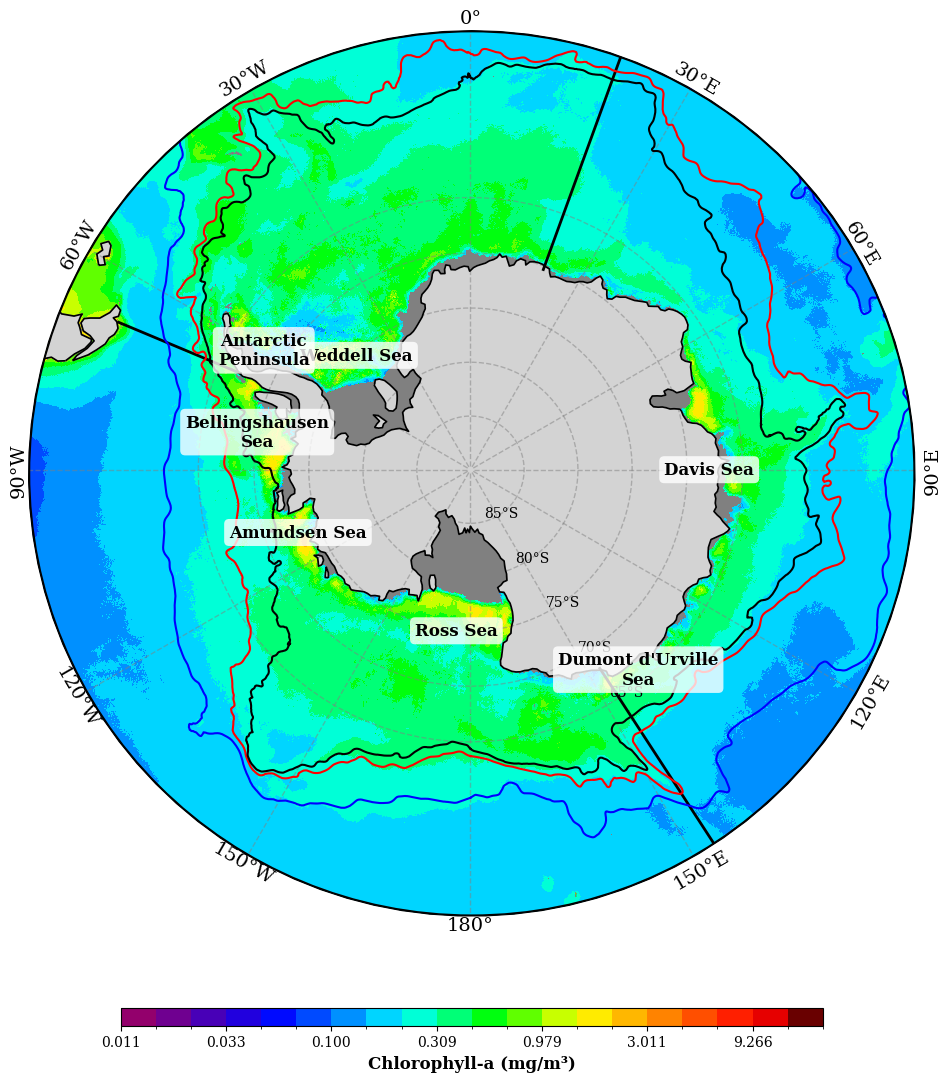

In [27]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = "serif"
fig = plt.figure(figsize=(12, 12))

# Create the first subplot - centered on Weddell Sea region
ax1 = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax1 = antarctic_map(ax1)
im1 = ax1.pcolormesh(ds_mean.lon, ds_mean.lat, ds_mean.CHL.values, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Add colorbar
cbar = plt.colorbar(im1, ax=ax1, orientation='horizontal', shrink=0.6, pad=0.08, aspect=40)
cbar.set_label('Chlorophyll-a (mg/m³)', fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


In [7]:
import os
import zipfile
import geopandas as gpd
import pandas as pd

# Define the path to the main folder
base_folder = '/A04/so_data/DATA/sea_ice/sea_ice_extent_shapefile'
months = ['01_Jan', '02_Feb', '03_Mar', '04_Apr', '05_May', '06_Jun', 
          '07_Jul', '08_Aug', '09_Sep', '10_Oct', '11_Nov', '12_Dec']

# The target CRS for NSIDC Polar Stereographic South (EPSG:3412)
target_crs = 'EPSG:3412'

# Create an empty list to store GeoDataFrames
gdf_list = []

# Loop through each month's folder
for month in os.listdir(base_folder):
    month_folder = os.path.join(base_folder, month)
    if os.path.isdir(month_folder):
        for file in os.listdir(month_folder):
            # Check for the specific polyline shapefile pattern
            if file.startswith('extent_S_') and 'polyline' in file and file.endswith('.zip'):
                zip_path = os.path.join(month_folder, file)
                with zipfile.ZipFile(zip_path, 'r') as z:
                    # Extract files and check their names
                    for shp_file in z.namelist():
                        if shp_file.endswith('.shp'):
                            # Extract only the shapefiles from the zip
                            z.extract(shp_file, month_folder)
                            # Read the shapefile
                            gdf = gpd.read_file(os.path.join(month_folder, shp_file))
                            
                            # Transform the CRS to the NSIDC Polar Stereographic South (EPSG:3412)
                            if gdf.crs != target_crs:
                                gdf = gdf.to_crs(target_crs)

                            # Extract the date from the filename
                            date_str = file.split('_')[2]  # Get the date part from the filename (e.g., '200711')
                            year = int(date_str[:4])
                            month_number = int(date_str[4:])  # Get the month as a number
                            # Create a datetime object for the first day of the month
                            date_time = pd.to_datetime(f"{year}-{month_number:02}-01")

                            # Add the date as a new column in the GeoDataFrame
                            gdf['time'] = date_time
                            
                            gdf_list.append(gdf)

# Concatenate all GeoDataFrames into one
merged_gdf = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True), crs=target_crs)

# Check the merged GeoDataFrame CRS
print(merged_gdf.crs)

EPSG:3412


In [8]:
merged_gdf.set_index('time', inplace=True)
merged_gdf.sort_index(inplace=True)
merged_gdf

,FID,geometry
time,,
1998-01-01,0,"MULTILINESTRING ((-1325000 2650000, -1325000 2..."
1998-02-01,0,"MULTILINESTRING ((-1300000 1450000, -1300000 1..."
1998-03-01,0,"MULTILINESTRING ((-2025000 2425000, -2025000 2..."
1998-04-01,0,"MULTILINESTRING ((-1925000 2550000, -1925000 2..."
1998-05-01,0,"MULTILINESTRING ((-1850000 2975000, -1850000 2..."
...,...,...
2021-08-01,0,"MULTILINESTRING ((700014.816 3925083.076, 7000..."
2021-09-01,0,"MULTILINESTRING ((825017.465 4000084.68, 82501..."
2021-10-01,0,"MULTILINESTRING ((3350070.826 575012.157, 3375..."


In [9]:
# Analyze sea ice extent data to find maximum extent per year (typically September)
import matplotlib.pyplot as plt

# Extract September data for each year
merged_gdf['year'] = merged_gdf.index.year
merged_gdf['month'] = merged_gdf.index.month

# Filter for September (month 9) - typically maximum extent in Antarctic
september_data = merged_gdf[merged_gdf['month'] == 9]

print(f"Total September records: {len(september_data)}")
print(f"Years covered: {september_data['year'].min()} to {september_data['year'].max()}")
print(f"\nSeptember data years: {sorted(september_data['year'].unique())}")


Total September records: 24
Years covered: 1998 to 2021

September data years: [np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]


In [10]:
# Find the single September with maximum sea ice extent
# We need to calculate the extent (length of the line) for each September

# Calculate the length/extent of each September geometry
september_data['extent_length'] = september_data.geometry.length

# Find the September with the maximum extent
max_extent_idx = september_data['extent_length'].idxmax()
max_extent_year = september_data.loc[max_extent_idx, 'year']
max_extent_value = september_data.loc[max_extent_idx, 'extent_length']

print(f"Maximum sea ice extent found in: {max_extent_idx}")
print(f"Year: {max_extent_year}")
print(f"Extent length: {max_extent_value:,.0f} meters")

# Get the geometry for the maximum extent
max_sea_ice_extent = september_data.loc[max_extent_idx, 'geometry']

print(f"\nMaximum sea ice extent geometry type: {max_sea_ice_extent.geom_type}")


Maximum sea ice extent found in: 2000-09-01 00:00:00
Year: 2000
Extent length: 30,900,000 meters

Maximum sea ice extent geometry type: MultiLineString


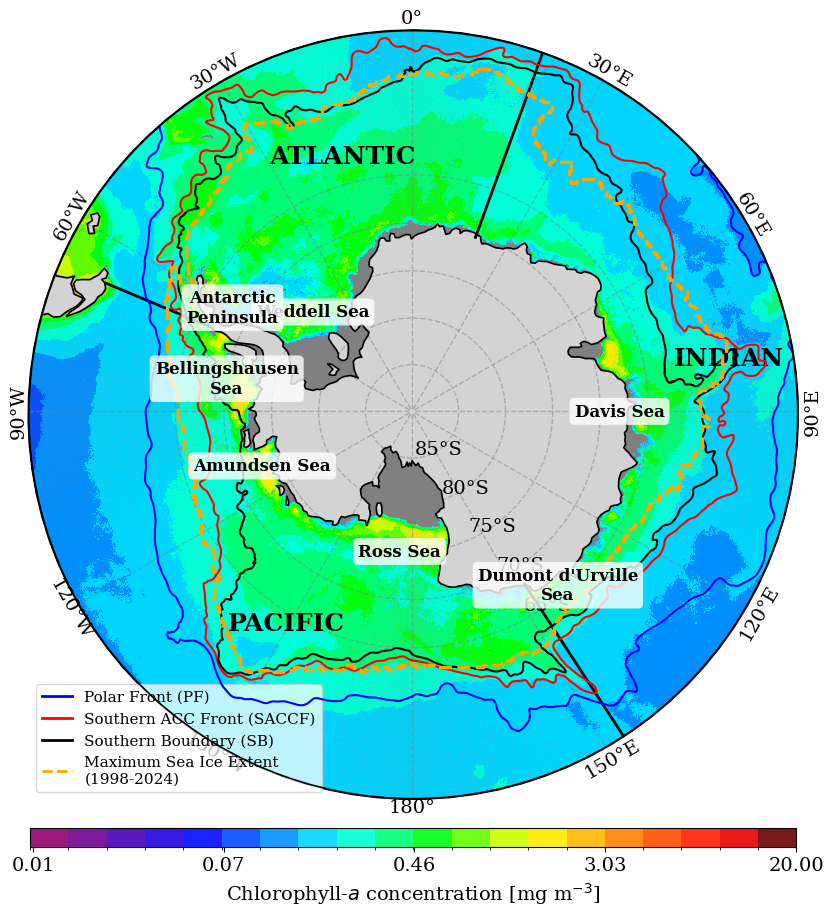

In [28]:
# Enhanced map with maximum sea ice extent (September 2000) and improved styling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from matplotlib.lines import Line2D

plt.rcParams['font.size'] = 14
plt.rcParams["font.family"] = "serif"
fig = plt.figure(figsize=(10, 10))

# Create the subplot
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax = antarctic_map(ax)

# Add chlorophyll data
im = ax.pcolormesh(ds_mean.lon, ds_mean.lat, ds_mean.CHL.values, 
                   cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), alpha=0.9)

# Add maximum sea ice extent (September 2000)
if max_sea_ice_extent.geom_type == 'MultiLineString':
    for geom in max_sea_ice_extent.geoms:
        ax.plot(*geom.xy, color='orange', linewidth=2.5, linestyle='--',
                transform=ccrs.epsg(3412), zorder=20)
else:
    ax.plot(*max_sea_ice_extent.xy, color='orange', linewidth=2.5, linestyle='--',
            transform=ccrs.epsg(3412), zorder=20)

# Add colorbar with proper positioning
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', 
                     shrink=0.8, pad=0.03, aspect=40)
cbar.ax.set_xlabel('Chlorophyll-${a}$ concentration [mg m$^{-3}$]')
tick_locs = [0.011, 0.07, 0.46, 3.03, 20]
tick_labels = [f"{loc:.2f}" for loc in tick_locs]
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels)
# Create custom legend with clarified front names
legend_elements = [
    Line2D([0], [0], color='blue', linewidth=2, label='Polar Front (PF)'),
    Line2D([0], [0], color='red', linewidth=2, label='Southern ACC Front (SACCF)'),
    Line2D([0], [0], color='black', linewidth=2, label='Southern Boundary (SB)'),
    Line2D([0], [0], color='orange',linestyle='--' ,linewidth=2, label=f'Maximum Sea Ice Extent\n(1998-2024)')
]

# Add legend outside the circular boundary
ax.legend(handles=legend_elements, loc='lower left', ncol=1,
          fontsize=11, framealpha=0.75, edgecolor=None)
ax.text(-30, -60, 'ATLANTIC', transform=ccrs.PlateCarree(), fontsize=18, fontweight='bold')
ax.text(80, -62, 'INDIAN', transform=ccrs.PlateCarree(), fontsize=18, fontweight='bold')
ax.text(-140, -60, 'PACIFIC', transform=ccrs.PlateCarree(), fontsize=18, fontweight='bold')

# plt.title('Antarctic Study Area: Chlorophyll-a with Maximum Sea Ice Extent', 
#           fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


**Figure 1. Study area and frontal zones in the Southern Ocean.** The map displays the spatial domain analyzed in this study, including Antarctic coastal waters and three major frontal zones: the Polar Front (PF, blue line), Southern Antarctic Circumpolar Current Front (SACCF, red line), and Southern Boundary (SB, black line). The orange dashed line indicates the climatological maximum sea ice extent observed during the study period (1998–2024). Colour shading indicates the climatological annual mean distribution of Copernicus GlobColour surface Chlorophyll‑a concentration (mg m⁻³), with higher values near the Antarctic margin and along frontal systems, highlighting regions of elevated phytoplankton biomass. Frontal positions are based on satellite altimetry-derived ocean dynamic topography (Park & Durand, 2019).